In [123]:
import joblib
import pandas as pd
from sklearn.metrics import classification_report
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
import shap

# Data preparing

In [124]:
data = pd.read_csv('./data-processed.csv')

In [125]:
data_year = data['Year']

In [126]:
data = data.drop(columns=['Year'])

In [127]:
data.head()

,Area,Food Inflation Rate,Raw GDP,GDP Growth Rate,Item,Item Price Per Tonne,Overall Inflation Rate,Import Rate,Export Rate,Unemployment Rate,Official Exchange Rate,label
0,0,0.059774,-0.422008,-0.726318,2,-0.304643,0.555556,-1.628717,-0.716019,0.893405,19.022788,0
1,0,0.059774,-0.422008,-0.726318,3,-0.236288,0.555556,-1.628717,-0.716019,0.893405,19.022788,0
2,0,0.059774,-0.422008,-0.726318,8,-0.335125,0.555556,-1.628717,-0.716019,0.893405,19.022788,0
3,0,0.059774,-0.422008,-0.726318,9,0.373454,0.555556,-1.628717,-0.716019,0.893405,19.022788,0
4,0,0.059774,-0.422008,-0.726318,15,-0.399215,0.555556,-1.628717,-0.716019,0.893405,19.022788,0


# Model training and evaluation

In [128]:
no_food_fraud_samples = len(data[data['label'] == 0])
food_fraud_samples = len(data[data['label'] == 1])
all_samples = len(data)
print(f"{no_food_fraud_samples / all_samples * 100}% of samples are without food fraud, while {food_fraud_samples / all_samples * 100}% are with food fraud")

92.82786885245902% of samples are without food fraud, while 7.172131147540983% are with food fraud


In [129]:
X, Y = data.drop(columns=['label']), data['label']
x_train, x_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=1)

classifier = RandomForestClassifier(
    n_estimators=30,
    max_depth=3,
    min_samples_split=10,
    min_samples_leaf=2,
    max_features='sqrt',
    random_state=42,
)
classifier.fit(x_train, y_train)

y_pred = classifier.predict(x_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.98      0.99      0.99      3202
           1       0.86      0.76      0.81       214

    accuracy                           0.98      3416
   macro avg       0.92      0.88      0.90      3416
weighted avg       0.98      0.98      0.98      3416



In [130]:
y_test.value_counts()

,count
label,
0,3202
1,214


# SHAP explainability

In [131]:
explainer = shap.TreeExplainer(classifier)
shap_values = explainer.shap_values(x_test)

The following plots and graphs illustrate the reasoning behind the model's decision to assign a label of 1, indicating that food fraud has been detected
for a specific set of features. While these visualizations are focused on the label of 1, the insights they provide can be similarly interpreted for cases where the label is 0, as the reasoning will be analogous. Therefore, we have chosen to execute them primarily for the label of 1. SHAP values quantify the contribution of each feature to a model's prediction for a given instance, providing understanding into how features impact the output. These values are retrieved based on the values in x_test, since this is the part of the dataset predictions are made on.

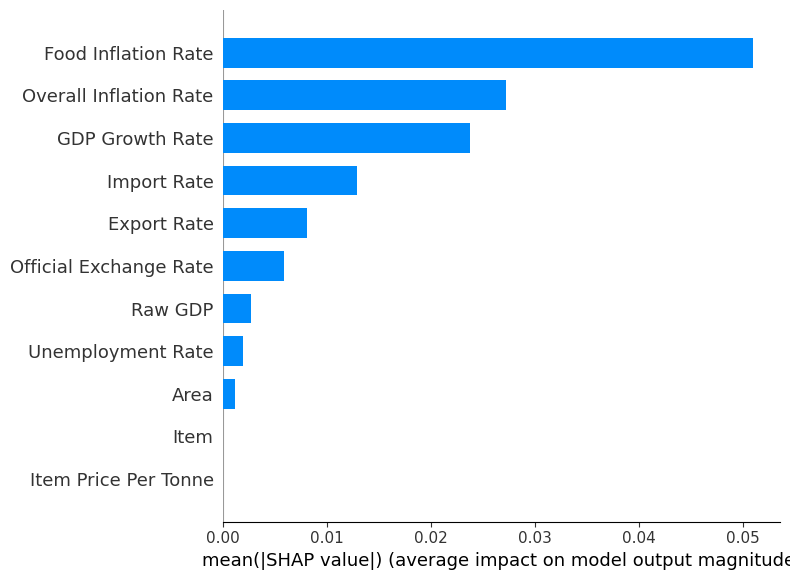

In [132]:
shap.summary_plot(shap_values[:, :, 1], x_test, plot_type="bar")

The plot above shows the average impact of each feature on the model output. "Food Inflation Rate" is the most influential factor, followed by "Overall Inflation Rate" and "GDP Growth Rate". These features have the largest impact on the model’s output, while others like "Area", "Item", and "Item Price Per Tonne" have much less effect. The results were expected, since the top two columns provide the most information when it comes to detecting food fraud. However, this plot is based on the absolute SHAP values, not taking into account whether the features affect the model output positively or negatively.

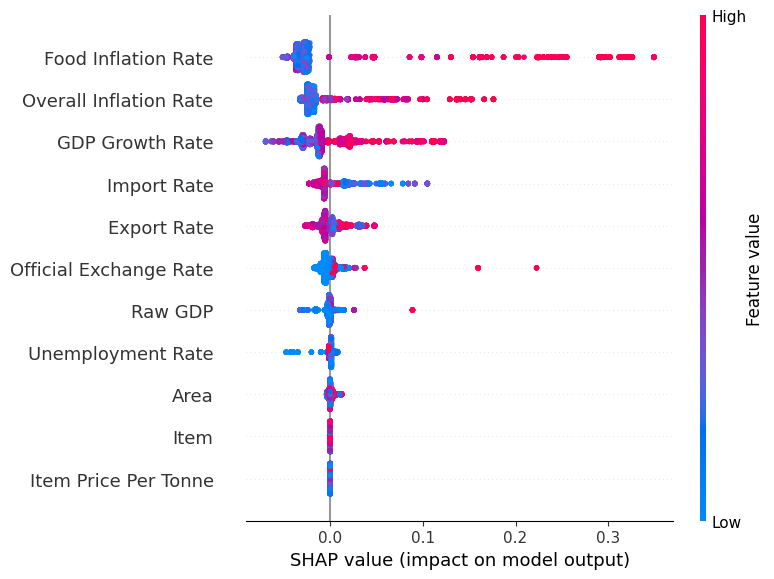

In [133]:
shap.summary_plot(shap_values[:, :, 1], x_test)

This plot provides a detailed view of how each feature’s low or high values affect the likelihood of food price fraud, as modeled by the classifier. Each point represents a SHAP value for a sample, and the color of each point illustrates the actual value of that feature for that sample—red for high values and blue for low values.
- For example, we see that high values of Food Inflation Rate (red points on the right) are strongly associated with large positive SHAP values, indicating a greater risk of food fraud, which aligns with the idea that rapidly rising food prices can create opportunities or incentives for fraudulent activity.
- Similarly, higher Overall Inflation Rate and GDP Growth Rate are also linked to increased model predictions for food fraud, suggesting that broader economic pressures and rapid economic expansion may heighten risk in the supply chain.
- Conversely, some features show substantial influence in the opposite direction. For instance, low values of Unemployment Rate (blue points with positive SHAP values) may signal stable economies where food fraud is more detectable or where controls are tighter, while high values sometimes dampen model output. This is logical, as stronger economies with lower unemployment, but higher inflation, might lead to market behaviors that raise food price fraud risk.
- Features like Import Rate and Export Rate also display patterns where both high and low values can affect risk, reflecting the complexities of trade flows on fraud vulnerability.

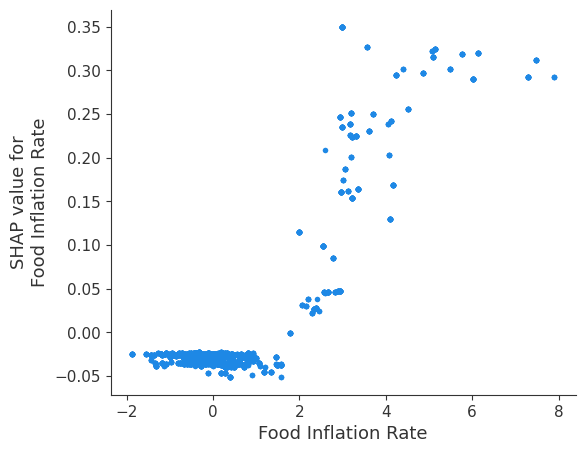

In [134]:
shap.dependence_plot("Food Inflation Rate", shap_values[:, :, 1], x_test, interaction_index=None)

This graph indicates that higher food inflation rate values have a greater impact on the model output (higher SHAP values).

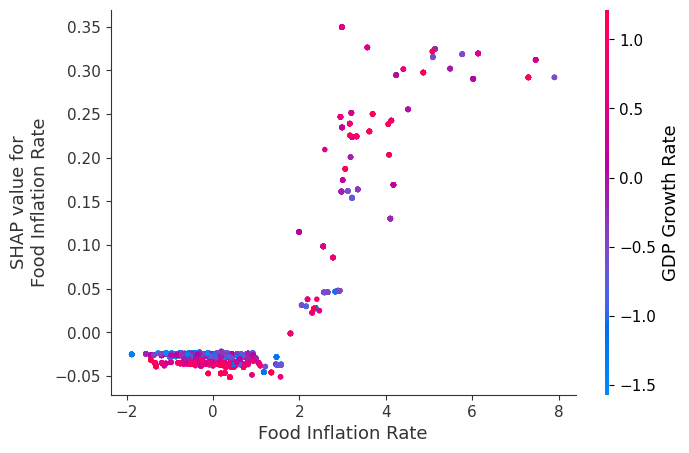

In [135]:
shap.dependence_plot('Food Inflation Rate', shap_values[:, :, 1], x_test)

This graph reveals that higher Food Inflation Rate values are associated with much stronger positive impacts on the model’s prediction. The clear color gradient also suggests that samples with higher GDP Growth Rates (pinker points) tend to have higher SHAP values for Food Inflation Rate. Thus, the effect of Food Inflation Rate on the prediction is intertwined with GDP Growth Rate, indicating interaction between these features.

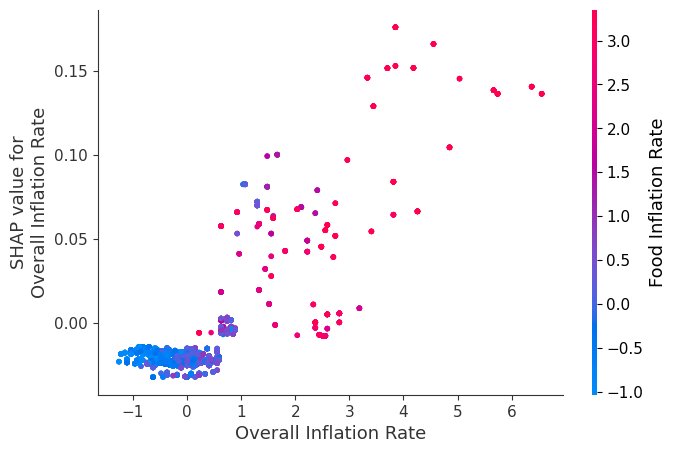

In [136]:
shap.dependence_plot(6, shap_values[:, :, 1], x_test)

From this graph, we see that higher values of Overall Inflation Rate are strongly linked to higher SHAP values—meaning, as Overall Inflation Rate increases, its contribution to the model output also increases. Additionally, the color gradient shows that higher Overall Inflation Rates often coincide with higher Food Inflation Rates (pinker points). This highlights an interaction: when both inflation rates are high, the positive impact on the prediction is even stronger.

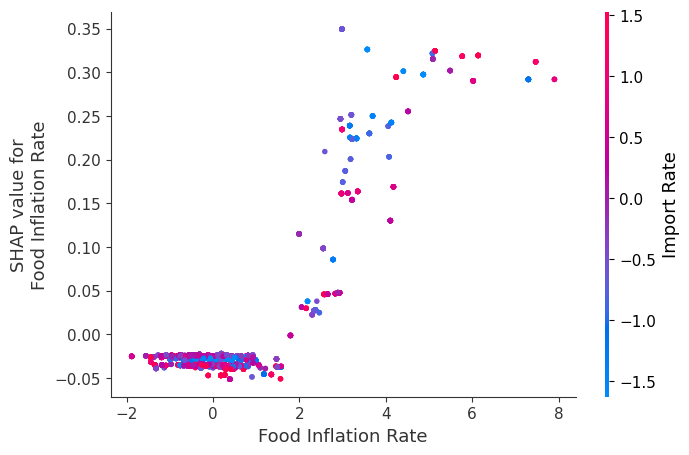

In [137]:
shap.dependence_plot('Food Inflation Rate', shap_values[:, :, 1], x_test, interaction_index="Import Rate")

This plot illustrates how the impact of Food Inflation Rate on the model’s predictions varies in relation to Import Rate. While higher Import Rates generally amplify the positive effect of Food Inflation Rate (shown by pink points), there are also many cases where Food Inflation Rate strongly influences the prediction even when Import Rate is low (blue points). This indicates that the model recognizes Food Inflation Rate as an important predictor on its own, but its influence can be further enhanced when coupled with higher Import Rates. The presence of blue points at higher SHAP values highlights that a strong Food Inflation Rate effect does not always require a high Import Rate.

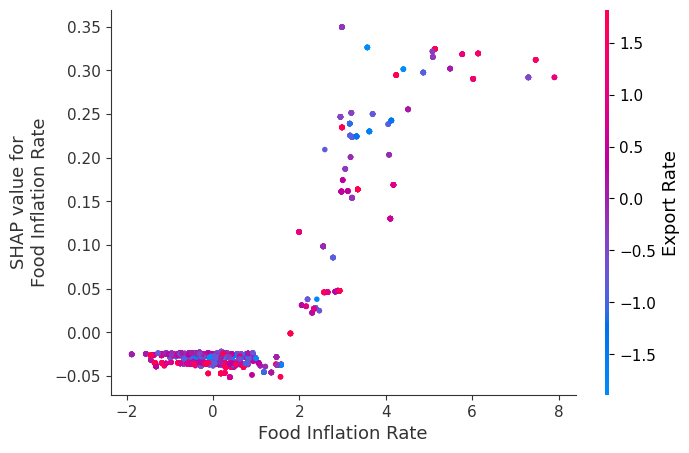

In [138]:
shap.dependence_plot('Food Inflation Rate', shap_values[:, :, 1], x_test, interaction_index="Export Rate")

This plot shows that as Food Inflation Rate increases, its impact on the model’s prediction also rises, and this effect is present across all levels of Export Rate. The spread of blue, purple, and pink points at higher Food Inflation Rates and SHAP values indicates that even when Export Rate is low (blue), Food Inflation Rate can still have a strong positive influence on the prediction. This suggests that while Export Rate does interact with Food Inflation Rate to some degree, the model often treats Food Inflation Rate as strongly predictive by itself.

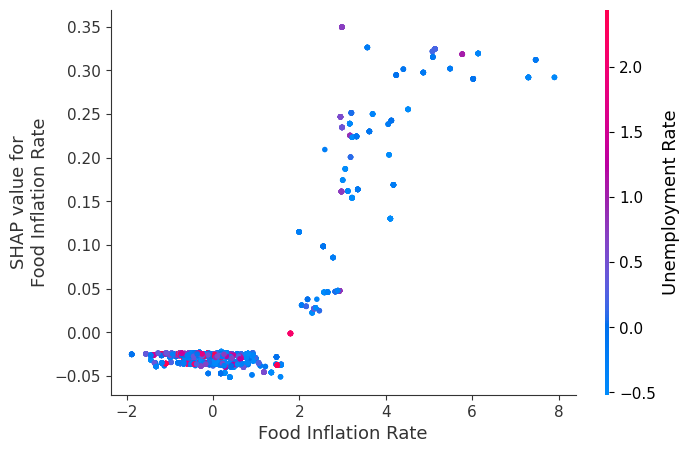

In [139]:
shap.dependence_plot('Food Inflation Rate', shap_values[:, :, 1], x_test, interaction_index="Unemployment Rate")

In this plot, we see that as Food Inflation Rate increases, its effect on the model’s prediction also grows, but most points at higher SHAP values are blue, indicating low Unemployment Rates. This suggests that the model often associates a strong impact from Food Inflation Rate with situations where Unemployment Rate is low, while higher Unemployment Rates (pink) are much less common among the cases with high Food Inflation Rate impact. In real-world terms, this may indicate that during healthier economic conditions with low unemployment, rising food inflation becomes a key signal linked to increased risk, such as food price fraud, possibly due to higher market demand and related pressures that create opportunities for fraudulent activities.

In [140]:
explainer = shap.Explainer(classifier, x_test)

In [141]:
explanation = explainer(x_test)

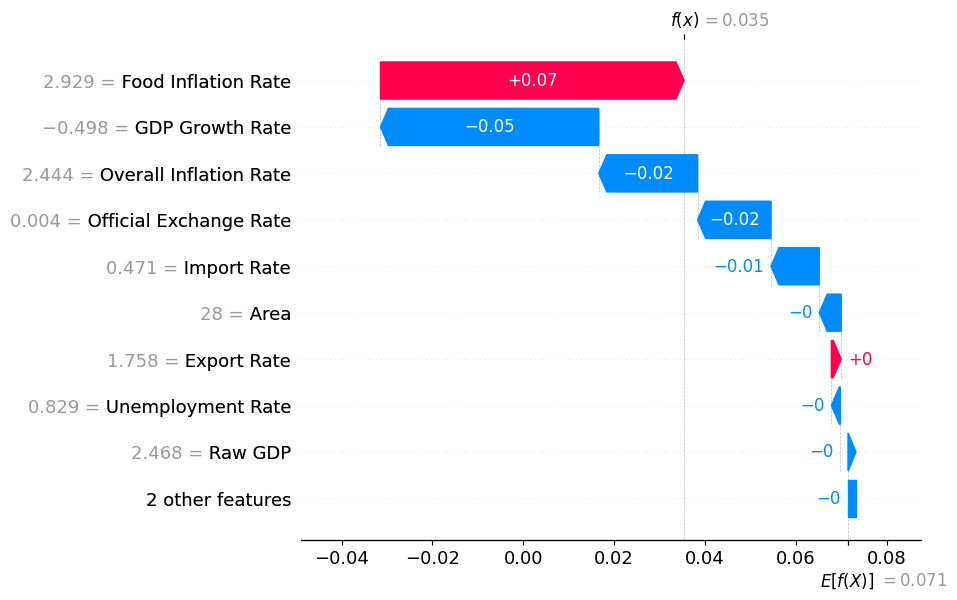

In [142]:
shap.waterfall_plot(explanation[30, :, 1])

This plot explains the output of the model through visualization of how this single row prediction is built beginning from the baseline (or "average") value, influenced by the contributions of individual features, which are sorted by the magnitude of their SHAP values. This baseline is typically the mean prediction of the model across the entire dataset, and in this case it is equal to 0.071. When it comes to the feature contributions:
* Food Inflation Rate (+0.07) is the only significant positive contributor, pushing the prediction higher and towards label 1, indicating a higher risk of food fraud.
*  GDP Growth Rate (–0.05), Overall Inflation Rate (–0.02), Official Exchange Rate (–0.02), Import Rate (–0.01), and Area (–0.01) push the prediction downward.
* The remaining features have a negligible effect.
The model predicts 0.035, which is very close to 0. This suggests that the model is confident in predicting label 0 rather than label 1.

In [143]:
numerical_columns = ['Food Inflation Rate', 'Raw GDP', 'Item Price Per Tonne', 'GDP Growth Rate',
                     'Overall Inflation Rate', 'Import Rate', 'Export Rate', 'Unemployment Rate',
                     'Official Exchange Rate']

In [144]:
scaler = joblib.load("scaler.joblib")
label_encoder = joblib.load("label_encoder.joblib")

/usr/local/lib/python3.11/dist-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator RobustScaler from version 1.5.1 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator LabelEncoder from version 1.5.1 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


In [145]:
data[numerical_columns] = scaler.inverse_transform(data[numerical_columns])

In [146]:
data['Area'] = data['Area'].astype(int)
data['Area'] = label_encoder.inverse_transform(data['Area'])

In [151]:
data['Year'] = data_year

In [152]:
x_test.iloc[30]

,15897
Area,28.000000
Food Inflation Rate,2.929338
Raw GDP,2.467794
GDP Growth Rate,-0.497618
Item,124.000000
Item Price Per Tonne,-0.269783
Overall Inflation Rate,2.444444
Import Rate,0.470624
Export Rate,1.757776
Unemployment Rate,0.829301


In [153]:
data.iloc[15897, :]

,15897
Area,Spain
Food Inflation Rate,11.607165
Raw GDP,1415874.440909
GDP Growth Rate,-2.059778
Item,124
Item Price Per Tonne,431.0
Overall Inflation Rate,8.3
Import Rate,7.74334
Export Rate,14.313204
Unemployment Rate,12.917


In [169]:
explainer.expected_value

array([0.92852942, 0.07147058])

Each value in the array represents the baseline (expected) model output for one of the classes:
* 0.9285 is the average predicted probability for class 0 (e.g., no fraud) over the background dataset.
* 0.0714 is the average predicted probability for class 1 (e.g., fraud).

In [170]:
shap.initjs()
shap.plots.force(explainer.expected_value[1], shap_values[:, :, 1], x_test)

/usr/local/lib/python3.11/dist-packages/shap/plots/_force.py:211: UserWarning: shap.plots.force is slow for many thousands of rows, try subsampling your data.
  warnings.warn("shap.plots.force is slow for many thousands of rows, try subsampling your data.")


The plot above is a force plot. It visualizes the impact of features on the prediction for multiple samples:
   * X-Axis: Represents the samples sorted by some criterion (in this case, by similarity).
   * Y-Axis: Shows the SHAP values, indicating how much each feature pushed the model's output from the base value.
   * Red areas: Indicate features that increase the prediction.
   * Blue areas: Indicate features that decrease the prediction.

The plot also reveals overall patterns in the dataset—most predictions cluster close to the base value for class 1, with predominantly blue areas showing that, for the majority of samples, the features reduce the likelihood of predicting class 1 (e.g., food fraud). However, on the far right, a subset of samples shows a sharp increase in red regions, indicating instances where features strongly increase the prediction.